In [16]:
# BLOCK 1: SETUP DATA & NORMALIZATION
# Mục tiêu: Tạo ra dữ liệu có quy luật y = 2x + 1 kèm nhiễu
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, matplotlib.pyplot as plt
# Khóa seed để kết quả chạy ngẫu nhiên luôn cố định (mọi người chạy đều ra kết quả giống nhau)
torch.manual_seed(42)
np.random.seed(42)

# 1. Tạo dữ liệu gốc theo hàm số quen thuộc y = 2x + 1
# Tạo 300 điểm dữ liệu cách đều trong khoảng từ -2 đến 2
X = np.linspace(-2, 2, 300).reshape(-1, 1)
# Cộng thêm nhiễu lớn (Noise) để làm mờ đường thẳng gốc, cố tình tạo đề bài khó để ép máy dễ học vẹt (Overfit)
y = 2 * X + 1 + np.random.normal(0, 0.4, X.shape)

# Đảo trộn ngẫu nhiên dữ liệu để tránh lệch pha
indices = np.arange(len(X))
np.random.shuffle(indices)
X, y = X[indices], y[indices]

# 2. Chuẩn hóa dữ liệu (Data Normalization) - Đưa X và y về đoạn [0, 1]
X_norm = (X - X.min()) / (X.max() - X.min())
y_norm = (y - y.min()) / (y.max() - y.min())

# Chuyển dữ liệu NumPy sang PyTorch Tensor để nạp vào mạng nơ-ron
X_tensor = torch.FloatTensor(X_norm)
y_tensor = torch.FloatTensor(y_norm)

# 3. Chia dữ liệu thành 2 tập riêng biệt: Tập Học (Train) và Tập Thi (Test)
# Dùng 80% dữ liệu để cho mô hình học thuộc, 20% còn lại dùng để thi thử xem có hiểu bài không
train_size = int(0.8 * len(X_tensor))
X_train, X_test = X_tensor[:train_size], X_tensor[train_size:]
y_train, y_test = y_tensor[:train_size], y_tensor[train_size:]

print(f"Tập Train (Để học): {len(X_train)} mẫu | Tập Test (Để thi): {len(X_test)} mẫu\n")

Tập Train (Để học): 240 mẫu | Tập Test (Để thi): 60 mẫu



In [17]:
# BLOCK 2: SETUP MODEL WITH DROPOUT
model = nn.Sequential(
    nn.Linear(1, 32),
    nn.Dropout(0.1),  # Mỗi bước học, cho 10% nơ-ron ngẫu nhiên đi ngủ để chống học vẹt
    nn.Linear(32, 1)   # Đầu ra hồi quy trả về 1 con số dự đoán
)
print("Đã khởi tạo mạng nơ-ron gọn nhẹ.")

Đã khởi tạo mạng nơ-ron gọn nhẹ.


In [18]:
# BLOCK 3: SETUP LOSS, OPTIMIZER & EARLY STOPPING (Chiến lược sửa sai)
criterion = nn.MSELoss() # Thước đo bình phương khoảng cách (chấm điểm sai số)
optimizer = optim.Adam(model.parameters(), lr=0.02) # Thuật toán Adam để sửa lỗi

train_losses, test_losses = [], []
patience = 10  # Ngưỡng kiên nhẫn: Nếu làm bài thi thử (Test Error) bị tệ đi 10 lần liên tiếp -> Dừng học ngay
best_test_loss = float('inf')
patience_counter = 0
max_epochs = 500

In [19]:
print("--- BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN ---")

for epoch in range(max_epochs):
    # 1. Giai đoạn Học (Train) - Bật Dropout để nơ-ron tự vận động
    model.train()
    optimizer.zero_grad()
    train_loss = criterion(model(X_train), y_train)
    train_loss.backward()
    optimizer.step()

    # 2. Giai đoạn Thi thử (Test) - Tắt Dropout để dự đoán chuẩn xác
    model.eval()
    with torch.no_grad():
        test_loss = criterion(model(X_test), y_test)

    # Lưu lại giá trị loss qua từng vòng để lát vẽ đồ thị
    train_losses.append(train_loss.item())
    test_losses.append(test_loss.item())

    # 3. Logic Early Stopping - Kiểm tra xem điểm thi thử có bị tụt liên tiếp không
    if test_loss.item() < best_test_loss:
        best_test_loss = test_loss.item()
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth') # Lưu lại bộ não tốt nhất
    else:
        patience_counter += 1 # Tăng bộ đếm nếu máy bắt đầu học vẹt nhiễu

    # Ngắt học nếu vượt quá giới hạn kiên nhẫn
    if patience_counter >= patience:
        print(f"==> EARLY STOPPING tại Epoch {epoch + 1}! Máy đã dừng học để tránh bị Overfitting.")
        break

print("--- HUẤN LUYỆN HOÀN TẤT ---")

--- BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN ---
==> EARLY STOPPING tại Epoch 58! Máy đã dừng học để tránh bị Overfitting.
--- HUẤN LUYỆN HOÀN TẤT ---


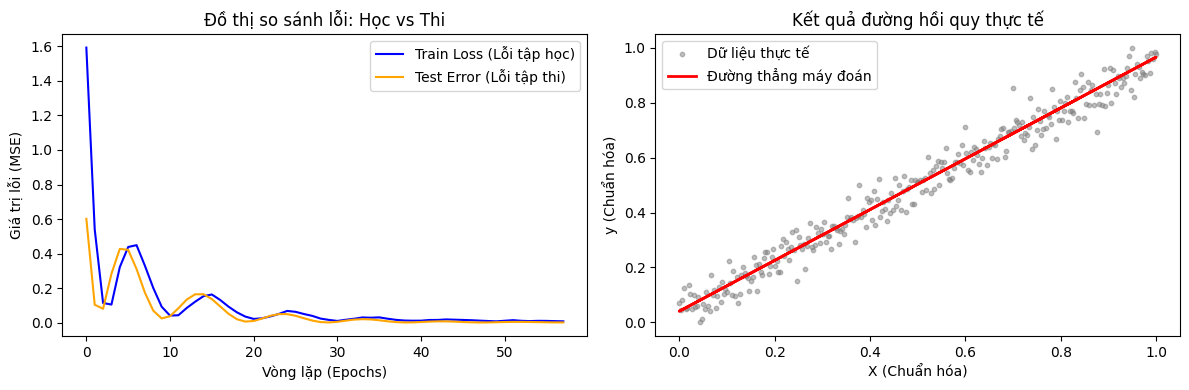

In [20]:
# Tải lại mô hình ở thời điểm đỉnh cao nhất trước khi bị học vẹt
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

with torch.no_grad():
    predictions = model(X_tensor).numpy()

# Tiến hành vẽ đồ thị phân tích kết quả
plt.figure(figsize=(12, 4))

# Đồ thị 1: So sánh Lỗi tập Học và Lỗi tập Thi để giải thích Early Stopping
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss (Lỗi tập học)', color='blue')
plt.plot(test_losses, label='Test Error (Lỗi tập thi)', color='orange')
plt.title('Đồ thị so sánh lỗi: Học vs Thi')
plt.xlabel('Vòng lặp (Epochs)')
plt.ylabel('Giá trị lỗi (MSE)')
plt.legend()

# Đồ thị 2: Đường hồi quy màu đỏ đi xuyên qua đống dữ liệu thực tế
plt.subplot(1, 2, 2)
plt.scatter(X_norm, y_norm, s=10, color='gray', alpha=0.5, label='Dữ liệu thực tế')
plt.plot(X_norm, predictions, color='red', linewidth=2, label='Đường thẳng máy đoán')
plt.title('Kết quả đường hồi quy thực tế')
plt.xlabel('X (Chuẩn hóa)')
plt.ylabel('y (Chuẩn hóa)')
plt.legend()

plt.tight_layout()
plt.show()